# CMU Machine Learning with Large Datasets

## Homework 3 - Coding 2: Machine Learning at Scale


Note that we've included code that does data loading and preparation for you. You could take a brief look to learn about how to specify a schema when loading data, or just run them all and start from "Part B Begins".

Note that we will not be autograding this notebook because of the open-ended nature of it (although you will have to submit this notebook). To make grading easier and to learn about your thought process, throughout the notebook, we include questions you have to anwswer in your writeup. Whenver this happens, there is a ✰ symbol.


### Start a Spark Session and Install Libraries


In [2]:
# You are highly recommended to select the "PySpark" kernel instead of python kernel,
# Otherwise you need to modify this cell to get pyspark working.

import pyspark
from pyspark.sql import *

sc = spark.sparkContext
print(f'num executors: {sc.getConf().get("spark.executor.instances")}')

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

num executors: 1

Throughout this assignment, you will be generating plots. `Matplotlib` and other useful Python libraries do not come pre-installed on the cluster. Therefore, you will have to ssh into your master node (think about why it should be the master) using your keypair created earlier and install `matplotlib`. You might have to do this later again for other libraries you use, e.g. `Pandas`.

Run the below cell to ensure you installation was successful. If an error occurs, you might want to double check your installation.


In [3]:
import matplotlib.pyplot as plt
import numpy as np

'''
Note : If you are having issues with your plots not showing, try running `%matplot plt` in a new code box after you have run the rest of the plotting code.
'''

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

'\nNote : If you are having issues with your plots not showing, try running `%matplot plt` in a new code box after you have run the rest of the plotting code.\n'

### Data Loading and Preparation

We are hosting the converted full raw Million Song Dataset in a public S3 bucket on AWS: https://us-east-1.console.aws.amazon.com/s3/buckets/10405-spring2025-hw3-msp.

Instead of asking you to download data on your own, we provide the S3 bucket name and script below to load the converted dataset from the S3 Storage for your convenience.

Note that although you can load all chunks of the dataset using `*`, we recommend you only load in a subset while developing so that processing takes shorter time when you are just verifying your ideas.


In [4]:
from pyspark.sql.types import DoubleType, StringType, StructField, StructType

schema = StructType(
    [StructField('song_hotttnesss', DoubleType(), True),
     StructField('artist_familiarity', DoubleType(), True),
     StructField('artist_hotttnesss', DoubleType(), True),
     StructField('artist_id', StringType(), True),
     StructField('artist_latitude', DoubleType(), True),
     StructField('artist_location', StringType(), True),
     StructField('artist_longitude', DoubleType(), True),
     StructField('artist_name', StringType(), True),
     StructField('title', StringType(), True),
     StructField('danceability', DoubleType(), True),
     StructField('duration', DoubleType(), True),
     StructField('end_of_fade_in', DoubleType(), True),
     StructField('energy', DoubleType(), True),
     StructField('key', DoubleType(), True),
     StructField('key_confidence', DoubleType(), True),
     StructField('loudness', DoubleType(), True),
     StructField('mode', DoubleType(), True),
     StructField('mode_confidence', DoubleType(), True),
     StructField('start_of_fade_out', DoubleType(), True),
     StructField('tempo', DoubleType(), True),
     StructField('time_signature', DoubleType(), True),
     StructField('time_signature_confidence', DoubleType(), True),
     StructField('artist_terms', StringType(), True),
     StructField('artist_terms_freq', StringType(), True),
     StructField('artist_terms_weight', StringType(), True),
     StructField('year', DoubleType(), True)]
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [5]:
#--------------------------------------------------------------------
# Set to False after writing your code and run end-to-end on full data
#--------------------------------------------------------------------
load_subset = True

#----------------------------
# DO NOT change the s3 bucket name below
#----------------------------
s3_bucket_name = '10405-spring2025-hw3-msp'

if load_subset:
    df = spark.read.format("csv")\
        .option("header", "false")\
        .option("nanValue", "nan")\
        .option("quote", "\"")\
        .option("escape", "\"")\
        .schema(schema)\
        .load(f"s3://{s3_bucket_name}/processed/A_1.csv")
else:
    df = spark.read.format("csv")\
        .option("header", "false")\
        .option("nanValue", "nan")\
        .option("quote", "\"")\
        .option("escape", "\"")\
        .schema(schema)\
        .load(f"s3://{s3_bucket_name}/processed/*.csv")

print('loaded {} records'.format(df.count()))

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

loaded 10000 records

Inspect the `df` we just created by running the below cell:


In [6]:
df.printSchema()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- song_hotttnesss: double (nullable = true)
 |-- artist_familiarity: double (nullable = true)
 |-- artist_hotttnesss: double (nullable = true)
 |-- artist_id: string (nullable = true)
 |-- artist_latitude: double (nullable = true)
 |-- artist_location: string (nullable = true)
 |-- artist_longitude: double (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- title: string (nullable = true)
 |-- danceability: double (nullable = true)
 |-- duration: double (nullable = true)
 |-- end_of_fade_in: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: double (nullable = true)
 |-- key_confidence: double (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: double (nullable = true)
 |-- mode_confidence: double (nullable = true)
 |-- start_of_fade_out: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- time_signature: double (nullable = true)
 |-- time_signature_confidence: double (nullable = true)
 |-- artist_terms: string

<div align="center">
    <h1>------------------- Part B Begins ------------------- </h1>
</div>


### 2.2.1 Exploratory Data Analysis

Now we have our data mostly ready. It's a good time to take some deeper look to better understand what we are dealing with here.

First, show summary statistics of the features using `.summary()`. Hint: because we have many features, the output might be too long for a single line. The simplest way to resolve this mess is to copy paste the output to some editor (e.g. vscode) and check the result. Another way is you could select only a few features to print at a time so that things could fit into one line.


In [7]:
# YOUR CODE HERE
df.summary().show(truncate=False)
# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+-------------------+------------------+-------------------+------------------+---------------+-----------------+----------------+-----------------+-----------------+------------+------------------+------------------+------+------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------+-------------------+-----------------+
|summary|song_hotttnesss    |artist_familiarity|artist_hotttnesss  |artist_id         |artist_latitude|artist_location  |artist_longitude|artist_name      |title            |danceability|duration          |end_of_fade_in    |energy|key               |key_confidence     |loudness          |mode   

Now looking at the statistics, `danceability` and `energy` appear strange.

✰2.2.1(a) Explain why these features seem problematic in your writeup.

Now we would like to make some histogram plots to inspect the distribution of feature values.

✰2.2.1(b) Plot histograms for `'song_hotttnesss', 'artist_familiarity', 'artist_hotttnesss', 'duration', 'tempo', 'year'`.

Note that one of these features may appear weird.

✰2.2.1(c) Explain what is weird about `year`'s distribution and what might cause this. Describe how you could filter `year` to make its histogram look more balanced. Hint: Choose a threshold and filter the `year` values.

✰2.2.1(d) Do it and include the new plot of this feature into your writeup.

Note: you may want to use the spark magic commands `%matplot plt` to show the plot.


In [8]:
# YOUR CODE HERE
sample_df = df.select("song_hotttnesss", "artist_familiarity", "artist_hotttnesss", 
                      "duration", "tempo", "year").toPandas()
features = ["song_hotttnesss", "artist_familiarity", "artist_hotttnesss", "duration", "tempo", "year"]

# YOUR CODE HERE
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    plt.hist(sample_df[feature].dropna(), bins=50, edgecolor="black")
    plt.title(feature)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

<AxesSubplot:>
(array([2.172e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 4.900e+01, 4.630e+02, 1.990e+02,
       3.040e+02, 5.200e+02, 1.500e+02, 2.060e+02, 3.110e+02, 2.970e+02,
       3.650e+02, 2.560e+02, 3.610e+02, 3.340e+02, 3.090e+02, 3.350e+02,
       3.540e+02, 3.300e+02, 3.290e+02, 3.040e+02, 2.820e+02, 2.520e+02,
       2.240e+02, 2.130e+02, 1.690e+02, 1.650e+02, 1.560e+02, 1.360e+02,
       1.080e+02, 7.200e+01, 5.800e+01, 6.500e+01, 4.700e+01, 3.500e+01,
       1.500e+01, 1.600e+01, 1.800e+01, 6.000e+00, 5.000e+00, 5.000e+00,
       1.000e+00, 4.000e+00]), array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
       0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
       0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]), <BarContainer object of 50

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

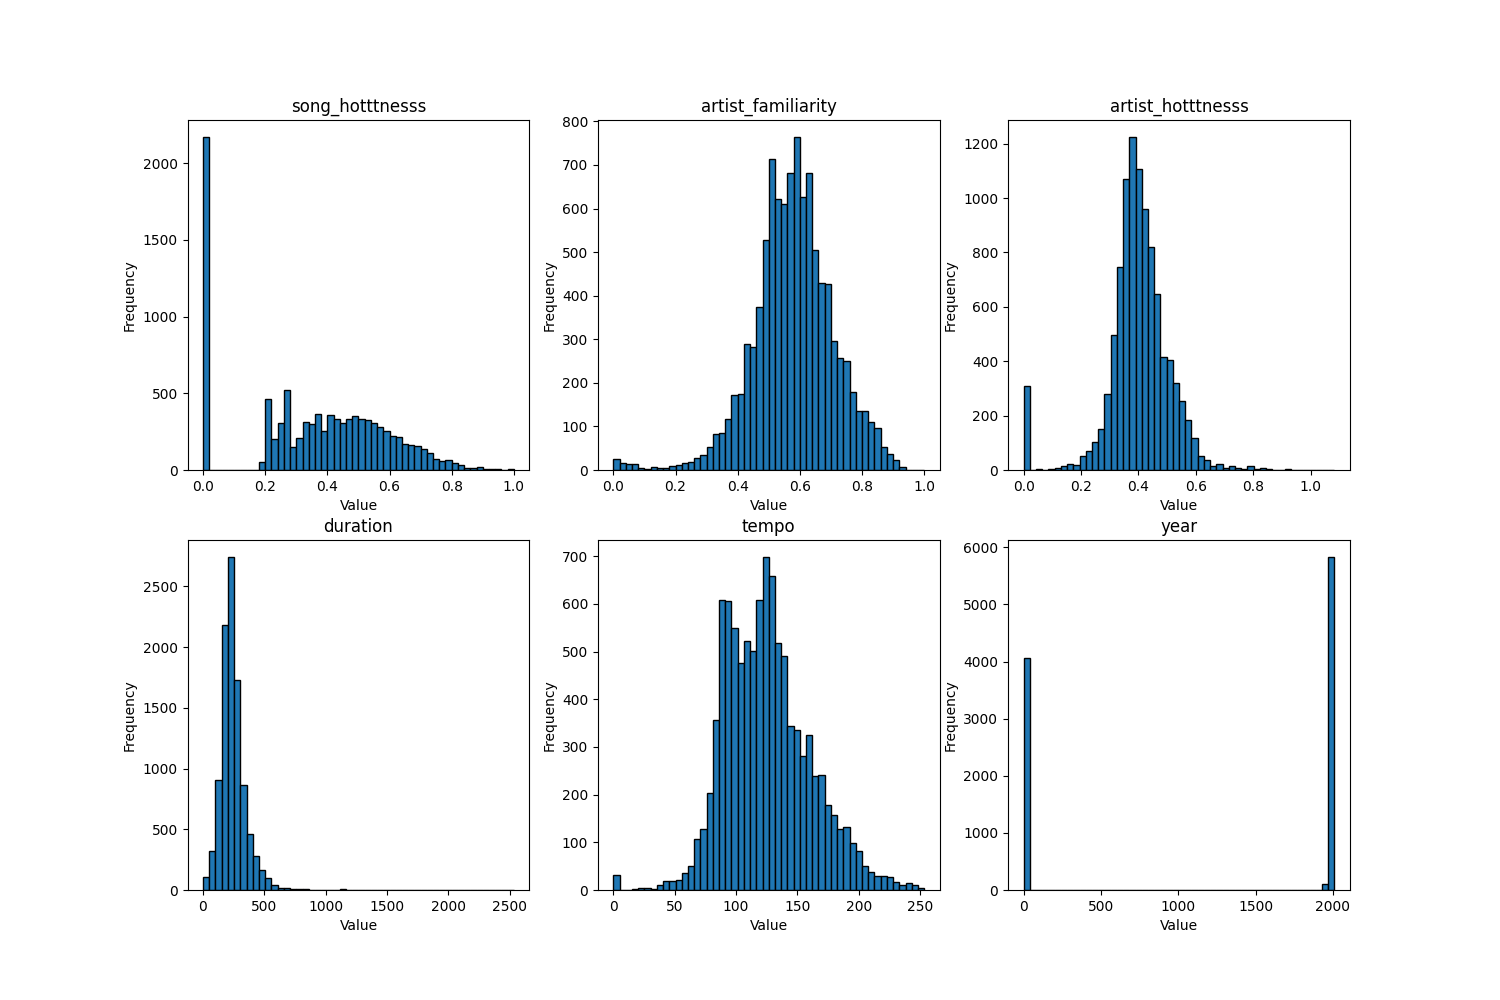

In [9]:
%matplot plt

In [10]:
filtered_sample_df = sample_df[sample_df["year"] >= 1900]

plt.figure(figsize=(6, 4))
plt.hist(filtered_sample_df["year"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Year (Filtered)")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

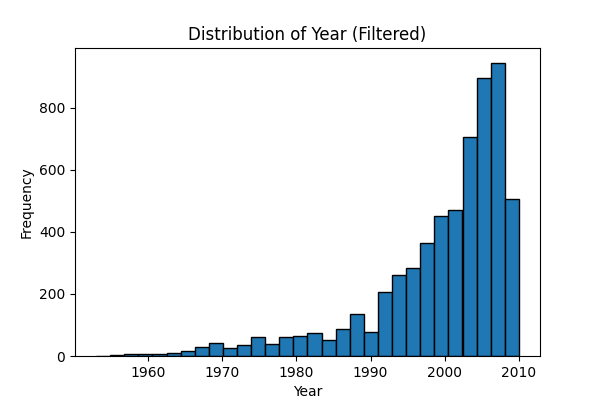

In [11]:
%matplot plt

Some scatter pair plots would also be interesting to see the correlation between features.

✰2.2.1(e) Include the plots of the following pairs of features and describe your findings (e.g. what patterns you observe) in your writeup.

- `song_hotttnesss` against `artist_familiarity`
- `artist_latitude` against `artist_longitude`
- `song_hotttnesss` against `year`

Plotting all data points might explode matplotlib. Think about what simple technique you could use to visualize large datasets while retaining data distribution. ✰2.2.1(f) In your writeup, briefly describe what you did.


In [12]:
sample_df = df.select("song_hotttnesss", "artist_familiarity", "artist_latitude", 
                      "artist_longitude", "year").toPandas()

filtered_sample_df = sample_df[sample_df["year"] >= 1900]

scatter_sample_df = filtered_sample_df.sample(n=1000, random_state=42)
scatter_sample_df = sample_df.sample(n=1000, random_state=42)


plt.figure(figsize=(15, 5))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(scatter_sample_df["artist_familiarity"], scatter_sample_df["song_hotttnesss"], alpha=0.5, s=10)
axes[0].set_xlabel("Artist Familiarity")
axes[0].set_ylabel("Song Hotttnesss")
axes[0].set_title("Song Hotttnesss vs. Artist Familiarity")

axes[1].scatter(scatter_sample_df["artist_latitude"], scatter_sample_df["artist_longitude"], alpha=0.5, s=10)
axes[1].set_xlabel("Artist Latitude")
axes[1].set_ylabel("Artist Longitude")
axes[1].set_title("Artist Latitude vs. Artist Longitude")

axes[2].scatter(scatter_sample_df["year"], scatter_sample_df["song_hotttnesss"], alpha=0.5, s=10)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Song Hotttnesss")
axes[2].set_title("Song Hotttnesss vs. Year")

plt.tight_layout()
plt.show()

# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

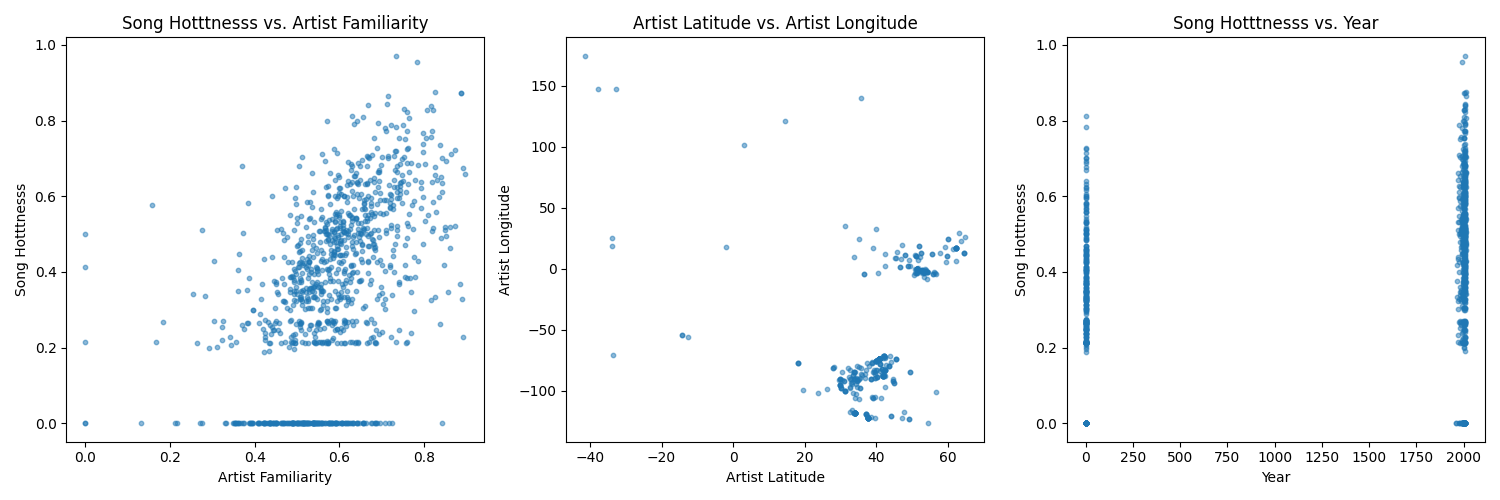

In [13]:
%matplot plt

### 2.2.2 Data Cleaning

From Section 3, you should have had a basic understanding of the dataset. In this cleaning step, we are dropping `energy` and `danceability` features.

✰2.2.2(a) In your writeup, justify why we are doing this.


In [14]:
# YOUR CODE HERE
df_cleaned = df.drop("energy", "danceability")

# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

For simplicity, we are dropping `year` values that are less or equal to 1920. Print out the number of samples before and after dropping these rows.

✰2.2.2(b) In your writeup, compare these two numbers and explain the advantages and potential problem of doing this step. What other techniques could you use to potentially do better?


In [15]:
# YOUR CODE HERE
num_samples_before = df_cleaned.count()
df_filtered = df_cleaned.filter(df_cleaned["year"] > 1920)
num_samples_after = df_filtered.count()

print(f"Number of samples before filtering: {num_samples_before}")
print(f"Number of samples after filtering: {num_samples_after}")
# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Number of samples before filtering: 10000
Number of samples after filtering: 5933

Now, let's do an NaN check to see if there are other problematic features. Print the number of entries that contain NaN for each feature.

Hint: use pyspark sql `count(when(isnull(...)))` to count total Null entries for a feature. Replace `isnull` with `isnan` to count nan entries.


In [16]:
# count na
from pyspark.sql.functions import isnan, when, count, isnull

# YOUR CODE HERE
null_counts = df_filtered.select([count(when(isnull(c), c)).alias(c) for c in df_filtered.columns])
nan_counts = df_filtered.select([count(when(isnan(c), c)).alias(c) for c in df_filtered.columns])

print("NULL Value Counts:")
null_counts.show()

print("NaN Value Counts:")
nan_counts.show()
# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

NULL Value Counts:
+---------------+------------------+-----------------+---------+---------------+---------------+----------------+-----------+-----+--------+--------------+---+--------------+--------+----+---------------+-----------------+-----+--------------+-------------------------+------------+-----------------+-------------------+----+
|song_hotttnesss|artist_familiarity|artist_hotttnesss|artist_id|artist_latitude|artist_location|artist_longitude|artist_name|title|duration|end_of_fade_in|key|key_confidence|loudness|mode|mode_confidence|start_of_fade_out|tempo|time_signature|time_signature_confidence|artist_terms|artist_terms_freq|artist_terms_weight|year|
+---------------+------------------+-----------------+---------+---------------+---------------+----------------+-----------+-----+--------+--------------+---+--------------+--------+----+---------------+-----------------+-----+--------------+-------------------------+------------+-----------------+-------------------+----+
|  

We should see two features that contain (a lot of) `nan` in them.

✰2.2.2(c) Which two are they?

For simplicity, we are dropping all records with `nan` in these two features. Note that this drops a significant proportion of our dataset. Since we have a lot of data to fit some rather simple models, this might be ok.

However, do note that this is not usually desirable in the real-word because we always want to retain as much data as possible, especially when training larger, more complex models.

✰2.2.2(d) In your writeup, explain what possible techniques could you employ to deal with this situation. Discuss the pros and cons of your proposed solution.


In [17]:
# YOUR CODE HERE
df_final = df_filtered.na.drop(subset=["artist_latitude", "artist_longitude"])
num_samples_after_drop = df_final.count()
print(f"Number of samples after dropping rows with NaN values in 'artist_latitude' and 'artist_longitude': {num_samples_after_drop}")
# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Number of samples after dropping rows with NaN values in 'artist_latitude' and 'artist_longitude': 2141

✰2.2.2(e) Finally in your writeup, report the percentage of records that survived our very aggressive data cleaning.


In [18]:
# counting code
num_samples_before_cleaning = df.count() 
num_samples_after_cleaning = df_final.count()  

percentage_survived = (num_samples_after_cleaning / num_samples_before_cleaning) * 100

print(f"Percentage of records that survived after aggressive data cleaning: {percentage_survived:.2f}%")


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Percentage of records that survived after aggressive data cleaning: 21.41%

### 2.2.3. Baseline

Now we have the data (almost) ready to do some preliminary modeling!

We will be treating this problem as a classification problem, i.e. given some features, predict whether a song will be popular. We define a song to be popular if its `song_hotttnesss` value is above average.

✰2.2.3(a) Explain in your writeup why treating this as a classification problem (instead of a regression problem) might be a sensible choice.

Then, assign labels to the dataset with the above definition of "popularity".


In [21]:
from pyspark.sql.functions import col, expr, when

# assign labels
# YOUR CODE HERE
df_labeled = df_final.withColumn(
    "popularity_label", when(col("song_hotttnesss") > expr("AVG(song_hotttnesss) OVER ()"), 1).otherwise(0))
# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Now let's take a look at how balanced the two classes are.

✰2.2.3(b) Report what percentage of songs are assigned the "popular" label.


In [22]:
# YOUR CODE HERE
total_count = df_labeled.count()
popular_count = df_labeled.filter(col("popularity_label") == 1).count()
popular_percentage = (popular_count / total_count) * 100
print(f"Percentage of popular songs: {popular_percentage:.2f}%")

# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Percentage of popular songs: 55.21%

As how we've been dealing with the `year` feature in earlier assignments, we will shift the feature so that it starts from 0.

✰2.2.3(c) Explain why we want to do this.


In [23]:
# shift years
# YOUR CODE HERE
min_year = df_labeled.agg({"year": "min"}).collect()[0][0]
df_shifted = df_labeled.withColumn("year_shifted", col("year") - min_year)

# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Finally, let's concatenate all features (using VectorAssembler) into a feature vector and scale it.

✰2.2.3(d) Explain what scaling means and why we want to perform scaling before the learning step.

Note: we will only be using the numeric features for now. Excluding `song_hotttnesss` and the two features we dropped in the data cleaning step, there should be 19-3=16 of them.


In [25]:
# assembling vector

from pyspark.ml.feature import VectorAssembler

# YOUR CODE HERE
input_feature_columns = [
    "artist_familiarity", "artist_hotttnesss", "duration", "end_of_fade_in",
    "key", "key_confidence", "loudness", "mode", "mode_confidence",
    "start_of_fade_out", "tempo", "time_signature", "time_signature_confidence",
    "year_shifted", "artist_latitude", "artist_longitude"] # Make a list of input features
vectorizer = VectorAssembler(inputCols=input_feature_columns, outputCol="features")
df_features = vectorizer.transform(df_shifted)

# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [26]:
# scaling

from pyspark.ml.feature import StandardScaler

# YOUR CODE HERE
stdscaler = StandardScaler(inputCol="features", outputCol="scaled_features")
stdscaler_model = stdscaler.fit(df_features)

df_features = stdscaler_model.transform(df_features)
# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Now let's verify the resulting feature vector is of expected length 16.


In [27]:
# change your variable/column names accordingly
l = df_features.select('features').take(1)[0].features
print('vector len:', len(l))
assert len(l) == 16

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

vector len: 16

Now, we are really ready to fit some models.

First, do a train-test split on the dataset, with test ratio 0.2 and seed 10605.


In [29]:
# YOUR CODE HERE
train_data, test_data = df_features.randomSplit([0.8, 0.2], seed=10605)

# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

We have to select a metric to evaluate our models on. For classification, potential choices include accuracy and AUC.

✰2.2.3(e) In your writeup, explain the difference between these two metrics and when AUC might be more useful than accuracy.

We will be going with AUC here. Instantiate an AUC Evaluator in the following cell.


In [30]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# YOUR CODE HERE
auc_evaluator = BinaryClassificationEvaluator(labelCol="popularity_label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
# YOUR CODE HERE

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

We will be fitting two models, logistic regression, and random forest, in the mandatory part. You have the chance go with fancier models in the last section to achieve higher accuracy to earn additional points.

Train a LR and a RF model with default hyperparameters.

✰2.2.3(f) Calculate the train and test AUC of both models and report them in your writeup.


In [ ]:
# Logistic Regression
from pyspark.ml.classification import LogisticRegression

# YOUR CODE HERE

# YOUR CODE HERE

In [ ]:
# Random Forest

from pyspark.ml.classification import RandomForestClassifier

# YOUR CODE HERE

# YOUR CODE HERE

### 2.2.4 Featurization: Bag-of-Words and TF-IDF

In our list of features, we have two features that contain text data, namely `title` and `artist_terms`. In the entity resolution task of HW1, we've seen how TF-IDF could help us featurize textual data. Let's do that here as well. [Bag-of-Words](https://en.wikipedia.org/wiki/Bag-of-words_model) is yet another technique (arguably simpler than TF-IDF) to featurize text features.

To get yourself familiar with both in Spark, let's treat titles and artist terms as mini documents and compute TF-IDF for `title` and BoW for `artist_terms`.


In [ ]:
# tf-idf on title

from pyspark.ml.feature import Tokenizer, HashingTF, IDF

TF_IDF_NUM_FEATS = 5 # HashingTF(..., numFeatures=TF_IDF_NUM_FEATS)

# YOUR CODE HERE
tokenizer = Tokenizer(inputCol="<FILL IN>", outputCol="<FILL IN>")
df_tf_idf = Tokenizer.<FILL IN>

hashing = HashingTF(inputCol="<FILL IN>", outputCol="<FILL IN>", numFeatures=TF_IDF_NUM_FEATS)
df_tf_idf = hashing.<FILL IN>

idf = IDF(inputCol="<FILL IN>", outputCol="<FILL IN>")
idfModel = idf.<FILL IN>
df_tf_idf = idfModel.<FILL IN>

# YOUR CODE HERE

Verify the resulting TF-IDF feature is indeed a vector of length `TF_IDF_NUM_FEATS`.


In [ ]:
# change variable/column name to yours
col_name = 'title_features'
head = df_tf_idf.select(col_name).head()
print(head)
assert type(head[col_name]) == pyspark.ml.linalg.SparseVector
assert len(head[col_name]) == TF_IDF_NUM_FEATS

Recall that `artist_terms` should be of type string array but we have not yet interpreted from a string literal. Let's do that now.

Hint: start by defining a UDF to convert a single string literal to type `T.ArrayType(T.StringType())`.


In [ ]:
from pyspark.sql.functions import udf
import pyspark.sql.types as T

# YOUR CODE HERE
def convert_string_of_array_to_array(input_string):
    output_array = <FILL IN>
    return output_array

convert_string_of_array_to_array_udf = udf(convert_string_of_array_to_array, T.ArrayType(T.StringType()))

df_tags_arr = df_tf_idf.withColumn("<FILL IN>", convert_string_of_array_to_array_udf("<FILL IN>"))

# YOUR CODE HERE


Let's do a quick check things indeed worked out.


In [ ]:
# change to your variable/column names
col_name = 'artist_terms_arr'
head = df_tags_arr.select(col_name).head()
print(head)
assert type(head[col_name]) == list

Now perform BoW on the array feature you just created.

✰2.2.4(a) In your writeup, explain what the `vocabSize` hyperparameter means in the context of Bag-of-Words. Remember you can tune this later in the last section.


In [ ]:
# BoW on artist_terms

from pyspark.ml.feature import CountVectorizer

BOW_VOCAB_SIZE = 10
BOW_MIN_DF = 2

# YOUR CODE HERE

cv = CountVectorizer(inputCol="<FILL IN>", outputCol="<FILL IN>", vocabSize=BOW_VOCAB_SIZE, minDF=BOW_MIN_DF)
cv_model = cv.<FILL IN>
df_final = cv_model.<FILL IN>

# YOUR CODE HERE

Verify the result of BoW is indeed a vector of length `BOW_VOCAB_SIZE`.


In [ ]:
# change variable/column name to yours
col_name = 'artist_terms_bow'
head = df_final.select(col_name).head()
print(head)
assert type(head[col_name]) == pyspark.ml.linalg.SparseVector
assert len(head[col_name]) == BOW_VOCAB_SIZE

✰2.2.4(b) Other than featurizing texts, what other feature engineering would you do on the dataset? Briefly describe one in your writeup.


Now with the new feature columns ready, let's assemble and scale our features once again as we did to prepare for training.

This time, we should have 16 features, plus the features we just created from TF-IDF and BoW. The total length of the resulting feature vector should be 31.

✰2.2.4(c) Explain where this number (31) comes from in your writeup.


In [ ]:
# assembling vector

# YOUR CODE HERE
input_feature_columns = <FILL IN>
vectorizer = VectorAssembler(inputCols=input_feature_columns, outputCol="<FILL IN>")

df_final = vectorizer.<FILL IN>

# YOUR CODE HERE

In [ ]:
# scaling

# YOUR CODE HERE
stdscaler = StandardScaler(inputCol="<FILL IN>", outputCol="<FILL IN>")
stdscaler_model = stdscaler.<FILL IN>

df_scaled_features = stdscaler_model.<FILL IN>


# YOUR CODE HERE
df_scaled_features.toPandas().head()

Now let's verify the feature vector is of expected length 31.


In [ ]:
# change your variable/column names accordingly
l = df_scaled_features.select('features').take(1)[0].features
print('vector len:', len(l))
assert len(l) == 31

### 2.2.5 Modeling with New Features


Now let's fit LR and RF on our new data. As before, first do a train-test split with test ratio 0.2 and seed 10605.


In [ ]:
# YOUR CODE HERE

# YOUR CODE HERE

Now train the LR and RF model with default hyperparameters.

✰2.2.5(a) Evaluate train and test AUC for each model and report them in your writeup.


In [ ]:
# Logistic Regression

# YOUR CODE HERE

# YOUR CODE HERE

In [ ]:
# Random Forest

# YOUR CODE HERE

# YOUR CODE HERE

Recall that AUC is the area under the ROC curve. Now, plot the ROC curves for the four models (including two baselines) in **one single plot**.

✰2.2.5(b) In your writeup:

- Include the plot (with legends)
- Explain how the ROC curve is derived and what it measures
- Explain, from the ROC curves, how do you discover which models are performing better than others, and in this case, which model performs the best.


In [ ]:
# YOUR CODE HERE

# YOUR CODE HERE

In [ ]:
def get_tpr_fpr(test_df):
    label_and_prob = test_df.select('popularlity', 'probability').rdd.map(
        lambda row: (float(row['popularlity']), float(row['probability'][1]))).collect()
    label_and_prob.sort(key=lambda x: x[1], reverse=True)
    labels_by_weight = np.array([k for (k, v) in label_and_prob])

    length = labels_by_weight.size
    true_positives = labels_by_weight.cumsum()
    num_positive = true_positives[-1]
    false_positives = np.arange(1.0, length + 1, 1.) - true_positives

    true_positive_rate = true_positives / num_positive
    false_positive_rate = false_positives / (length - num_positive)

    return true_positive_rate, false_positive_rate

In [ ]:
# YOUR CODE HERE
pr_lr_baseline, fpr_lr_baseline = get_tpr_fpr(<FILL IN>)
tpr_rf_baseline, fpr_rf_baseline = get_tpr_fpr(<FILL IN>)
tpr_lr, fpr_lr = get_tpr_fpr(<FILL IN>)
tpr_rf, fpr_rf = get_tpr_fpr(<FILL IN>)
# YOUR CODE HERE

In [ ]:
def prepare_plot(xticks, yticks, figsize=(10.5, 6), hide_labels=False, grid_color='#999999',
                 grid_width=1.0):
    """Template for generating the plot layout."""
    plt.close()
    fig, ax = plt.subplots(figsize=figsize, facecolor='white', edgecolor='white')
    ax.axes.tick_params(labelcolor='#999999', labelsize='10')
    for axis, ticks in [(ax.get_xaxis(), xticks), (ax.get_yaxis(), yticks)]:
        axis.set_ticks_position('none')
        axis.set_ticks(ticks)
        axis.label.set_color('#999999')
        if hide_labels:
            axis.set_ticklabels([])
    plt.grid(color=grid_color, linewidth=grid_width, linestyle='-')
    map(lambda position: ax.spines[position].set_visible(False), ['bottom', 'top', 'left', 'right'])
    return fig, ax

In [ ]:
fig, ax = prepare_plot(np.arange(0., 1.1, 0.1), np.arange(0., 1.1, 0.1))
ax.set_xlim(-.05, 1.05), ax.set_ylim(-.05, 1.05)
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
plt.plot(fpr_lr_baseline, tpr_lr_baseline, color='r', label="LogisticRegressionBaseline")
plt.plot(fpr_rf_baseline, tpr_rf_baseline, color='g', label="RandomForestBaseline")
plt.plot(fpr_lr, tpr_lr, color='b', label="LogisticRegression")
plt.plot(fpr_rf, tpr_rf, color='orange', label="RandomForest")
plt.plot((0., 1.), (0., 1.), linestyle='--', color='#d6ebf2',
         linewidth=2., label="baseline")  # Baseline model
plt.legend()

### 2.2.6 Do Your Best


In all previous sections in this assignment and other assignments so far, we have almost specified everything you should do. You might be (and should be!) bored by now. This section gives you a chance to do whatever you want to improve the prediction AUC.

You can do better data preprocessing, feature engineering, fit fancier models, perform hyperparameter tuning, etc.

✰2.2.6 after you are satisfied with your model, report in your writeup

- the hyperparameters,
- train and test AUC of your optimized model, and
- the approach you took on top of the specified instructions to obtain this better result.


In [ ]:
# have fun!

### 2.2.7 Don't forget to answer the reflection question on the writeup! ✰2.2.7
